In [3]:
%pip install pandas numpy matplotlib scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv("../data/job_salary_prediction_dataset.csv")

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [6]:
df.shape

(250000, 10)

In [7]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [9]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [10]:
df = df.drop_duplicates()

df.shape

(250000, 10)

In [11]:
text_columns = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

for col in text_columns:
    df[col] = df[col].str.strip()

In [12]:
for col in text_columns:
    print(col)
    print(df[col].unique())
    print()

job_title
<StringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str

education_level
<StringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str

industry
<StringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str

company_size
<StringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str

location
<StringArray>
[      'India',   'Australia',   'Singapore',      'Canada',      'Sweden',
         'USA', 'Netherlands',      'Remote',     'Germany',      

In [13]:
df["salary"].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

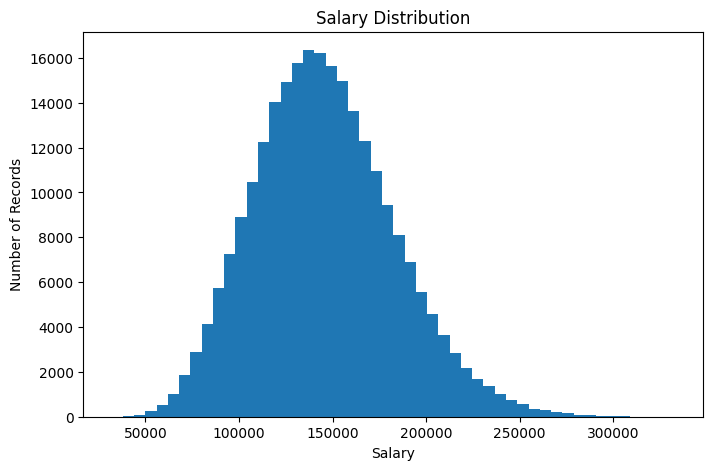

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["salary"], bins=50)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Records")
plt.show()

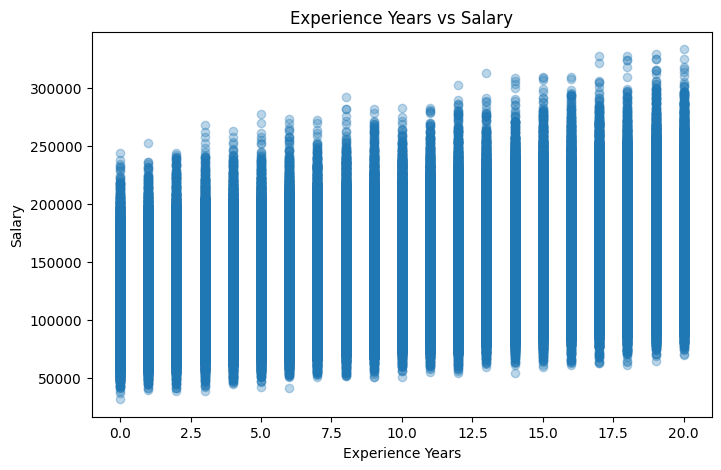

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df["experience_years"], df["salary"], alpha=0.3)
plt.title("Experience Years vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()

In [16]:
df = df[
    (df["experience_years"] >= 0) &
    (df["experience_years"] <= 50) &
    (df["skills_count"] >= 0) &
    (df["certifications"] >= 0) &
    (df["salary"] > 0)
]

df.shape

(250000, 10)

In [17]:
X = df.drop("salary", axis=1)
y = df["salary"]

In [18]:
categorical_features = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

numeric_features = [
    "experience_years",
    "skills_count",
    "certifications"
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [22]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [23]:
y_pred = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 5019.38038021
R2 Score: 0.9712254112541766


In [25]:
sample_cv = pd.DataFrame([{
    "job_title": "Software Engineer",
    "experience_years": 2,
    "education_level": "Bachelor",
    "skills_count": 8,
    "industry": "Technology",
    "company_size": "Medium",
    "location": "South Africa",
    "remote_work": "Yes",
    "certifications": 1
}])

predicted_salary = model.predict(sample_cv)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 106893.63


In [26]:
sample_cv = pd.DataFrame([{
    "job_title": "Junior Web Developer",
    "experience_years": 0,
    "education_level": "High School",
    "skills_count": 2,
    "industry": "Technology",
    "company_size": "Small",
    "location": "South Africa",
    "remote_work": "No",
    "certifications": 0
}])

print(model.predict(sample_cv))

[87008.17]


In [28]:
sample_cv = pd.DataFrame([{
    "job_title": "Senior AI Engineer",
    "experience_years": 15,
    "education_level": "PhD",
    "skills_count": 20,
    "industry": "Technology",
    "company_size": "Small",
    "location": "South Africa",
    "remote_work": "No",
    "certifications": 10
}])

print(model.predict(sample_cv))

[164122.46]


In [27]:
joblib.dump(model, "../model/salary_model.pkl")

['../model/salary_model.pkl']